<a href="https://colab.research.google.com/github/Janmeshree/DAV-PRACS/blob/main/DAV_TIME_SERIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [41]:
date_range = pd.date_range(start="2020-01-01", periods=500, freq="D")

trend = np.linspace(10, 50, 500)
seasonality = 10 * np.sin(np.linspace(0, 20, 500))
noise = np.random.normal(0, 2, 500)

values = trend + seasonality + noise

df = pd.DataFrame({"Date": date_range, "Value": values})

df.set_index("Date", inplace=True)

df.head()

,Value
Date,
2020-01-01,10.993428
2020-01-02,10.204326
2020-01-03,12.256443
2020-01-04,14.486050
2020-01-05,11.448682


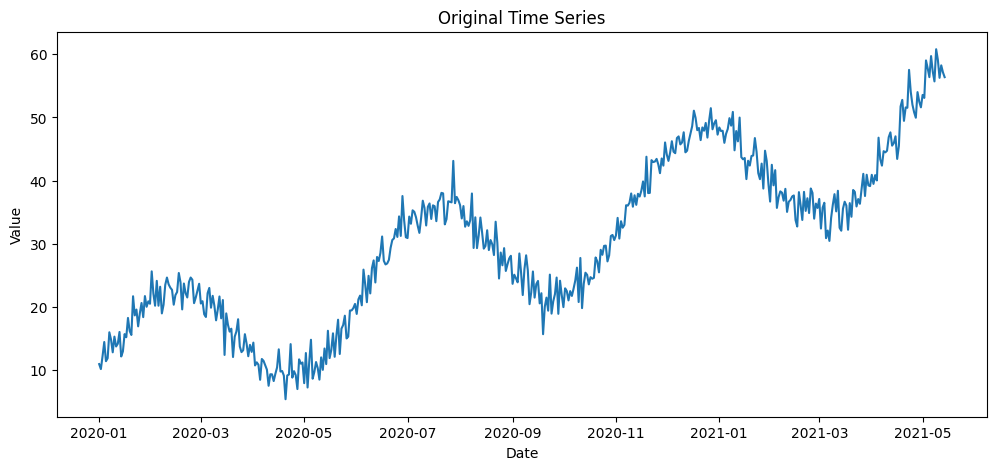

In [42]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Value"])
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

In [43]:
result = adfuller(df["Value"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.7014048307495677
p-value: 0.4303888115443403


In [44]:
def create_lag_features(data, lags=7):
    df_lag = pd.DataFrame(data)

    for i in range(1, lags+1):
        df_lag[f'lag_{i}'] = df_lag["Value"].shift(i)

    df_lag.dropna(inplace=True)
    return df_lag

lagged_df = create_lag_features(df, lags=7)

lagged_df.head()

,Value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
Date,,,,,,,,
2020-01-08,14.864940,16.021085,11.923149,11.448682,14.486050,12.256443,10.204326,10.993428
2020-01-09,12.854086,14.864940,16.021085,11.923149,11.448682,14.486050,12.256443,10.204326
2020-01-10,15.336056,12.854086,14.864940,16.021085,11.923149,11.448682,14.486050,12.256443
2020-01-11,13.776333,15.336056,12.854086,14.864940,16.021085,11.923149,11.448682,14.486050
2020-01-12,14.217675,13.776333,15.336056,12.854086,14.864940,16.021085,11.923149,11.448682


In [45]:
train_size = int(len(lagged_df) * 0.8)

train = lagged_df.iloc[:train_size]
test = lagged_df.iloc[train_size:]

X_train = train.drop("Value", axis=1)
y_train = train["Value"]

X_test = test.drop("Value", axis=1)
y_test = test["Value"]

In [46]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest Results
MAE: 3.484644436209688
RMSE: 4.782229984752508


In [47]:
arima_model = ARIMA(df["Value"], order=(5,1,0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(y_test))

mae_arima = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))

print("ARIMA Results")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

ARIMA Results
MAE: 14.758818151707688
RMSE: 16.772961251331424


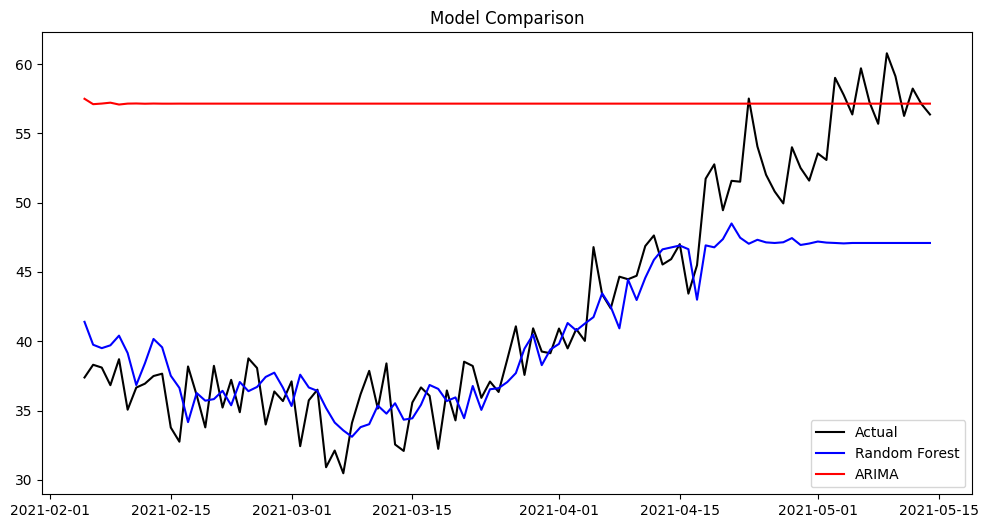

In [48]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual", color="black")
plt.plot(y_test.index, rf_predictions, label="Random Forest", color="blue")
plt.plot(y_test.index, arima_forecast, label="ARIMA", color="red")

plt.title("Model Comparison")
plt.legend()
plt.show()

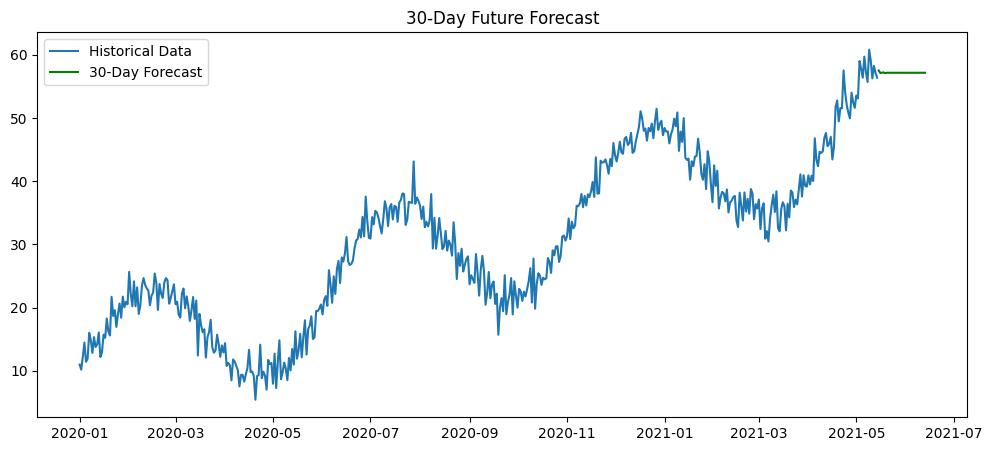

In [49]:
future_forecast = arima_fit.forecast(steps=30)

future_index = pd.date_range(df.index[-1], periods=31, freq="D")[1:]

plt.figure(figsize=(12,5))

plt.plot(df.index, df["Value"], label="Historical Data")
plt.plot(future_index, future_forecast, label="30-Day Forecast", color="green")

plt.title("30-Day Future Forecast")
plt.legend()
plt.show()